<a href="https://colab.research.google.com/github/Dharuneswar/CarPoolingProject/blob/master/bankruptcy4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [ ]:

df = pd.read_csv('/content/drive/MyDrive/Bankruptcy.csv')

df


,BankruptcyFlag,ROA_PreTax_DepAdj,ROA_AfterTax,ROA_BookDep,GrossMargin_Op,GrossMargin_Realized,OpProfit_Margin,NetMargin_PreTax,NetMargin_AfterTax,NonOp_RevRatio,...,NetIncome_to_Assets,Assets_to_GNP,NoCredit_Period,GrossProfit_to_Sales,NetIncome_to_Equity,Liabilities_to_Equity,DFL,InterestCoverage,NetIncome_PositiveFlag,Equity_to_Liabilities
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [ ]:
df.head()

,BankruptcyFlag,ROA_PreTax_DepAdj,ROA_AfterTax,ROA_BookDep,GrossMargin_Op,GrossMargin_Realized,OpProfit_Margin,NetMargin_PreTax,NetMargin_AfterTax,NonOp_RevRatio,...,NetIncome_to_Assets,Assets_to_GNP,NoCredit_Period,GrossProfit_to_Sales,NetIncome_to_Equity,Liabilities_to_Equity,DFL,InterestCoverage,NetIncome_PositiveFlag,Equity_to_Liabilities
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
#checked the null values
df.isnull().sum()


,0
BankruptcyFlag,0
ROA_PreTax_DepAdj,0
ROA_AfterTax,0
ROA_BookDep,0
GrossMargin_Op,0
...,...
Liabilities_to_Equity,0
DFL,0
InterestCoverage,0
NetIncome_PositiveFlag,0


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   BankruptcyFlag               6819 non-null   int64  
 1   ROA_PreTax_DepAdj            6819 non-null   float64
 2   ROA_AfterTax                 6819 non-null   float64
 3   ROA_BookDep                  6819 non-null   float64
 4   GrossMargin_Op               6819 non-null   float64
 5   GrossMargin_Realized         6819 non-null   float64
 6   OpProfit_Margin              6819 non-null   float64
 7   NetMargin_PreTax             6819 non-null   float64
 8   NetMargin_AfterTax           6819 non-null   float64
 9   NonOp_RevRatio               6819 non-null   float64
 10  InterestRate_Consistent      6819 non-null   float64
 11  OpExpense_to_Rev             6819 non-null   float64
 12  RDE_to_Rev                   6819 non-null   float64
 13  CashFlow_to_Assets

In [ ]:
#visualizing the Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(96,96))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

In [ ]:
#seen the corelation values of targetvariable to remaining
trel = df.corr()['BankruptcyFlag']
trel = trel.sort_values(ascending=False)
trel

,BankruptcyFlag
BankruptcyFlag,1.000000
DebtRatio_Total,0.250161
CL_to_TotalLiabilities,0.194494
Debt_Reliance,0.176543
CL_to_CA,0.171306
...,...
ROA_PreTax_DepAdj,-0.260807
ROA_BookDep,-0.273051
ROA_AfterTax,-0.282941
NetIncome_to_Assets,-0.315457


In [ ]:
#feature engineering


In [ ]:
df['CashFlow_to_Assets_NetProfit_Growth'] = df['CashFlow_to_Assets'] * df['NetProfit_Growth']
df['Debt_to_Equity_InterestCoverage'] = df['Debt_to_Equity'] * df['InterestCoverage']
df['InventoryAR_to_NetValue_AssetTurnover'] = df['InventoryAR_to_NetValue'] * df['AssetTurnover']
df.head()

,BankruptcyFlag,ROA_PreTax_DepAdj,ROA_AfterTax,ROA_BookDep,GrossMargin_Op,GrossMargin_Realized,OpProfit_Margin,NetMargin_PreTax,NetMargin_AfterTax,NonOp_RevRatio,...,GrossProfit_to_Sales,NetIncome_to_Equity,Liabilities_to_Equity,DFL,InterestCoverage,NetIncome_PositiveFlag,Equity_to_Liabilities,CashFlow_to_Assets_NetProfit_Growth,Debt_to_Equity_InterestCoverage,InventoryAR_to_NetValue_AssetTurnover
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469,0.315651,0.011995,0.034612
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794,0.318547,0.007129,0.025640
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474,0.316133,0.011977,0.006096
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982,0.320922,0.005405,0.035795
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490,0.319155,0.002964,0.070179


In [ ]:
#delete unnecessary columns
df.drop(['CashFlow_to_Assets', 'NetProfit_Growth', 'Debt_to_Equity', 'InterestCoverage', 'InventoryAR_to_NetValue', 'AssetTurnover'], axis=1, inplace=True)
df.head()

,BankruptcyFlag,ROA_PreTax_DepAdj,ROA_AfterTax,ROA_BookDep,GrossMargin_Op,GrossMargin_Realized,OpProfit_Margin,NetMargin_PreTax,NetMargin_AfterTax,NonOp_RevRatio,...,NoCredit_Period,GrossProfit_to_Sales,NetIncome_to_Equity,Liabilities_to_Equity,DFL,NetIncome_PositiveFlag,Equity_to_Liabilities,CashFlow_to_Assets_NetProfit_Growth,Debt_to_Equity_InterestCoverage,InventoryAR_to_NetValue_AssetTurnover
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.622879,0.601453,0.827890,0.290202,0.026601,1,0.016469,0.315651,0.011995,0.034612
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.623652,0.610237,0.839969,0.283846,0.264577,1,0.020794,0.318547,0.007129,0.025640
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.623841,0.601449,0.836774,0.290189,0.026555,1,0.016474,0.316133,0.011977,0.006096
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.622929,0.583538,0.834697,0.281721,0.026697,1,0.023982,0.320922,0.005405,0.035795
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.623521,0.598782,0.839973,0.278514,0.024752,1,0.035490,0.319155,0.002964,0.070179


In [ ]:
# df.drop([
#     "CurrentAssets_to_Assets", "Cash_to_Assets", "QuickAssets_to_CL", "CL_to_TotalLiabilities",
#     "OpProfit_PerEmployee", "CostPerEmployee", "ROA_AfterTax", "ROA_BookDep",
#     "EPS_NetValueA", "EPS_NetValueC", "EPS_Persistent4Q", "NetProfit_Regular_Growth",
#     "NetProfit_ConsistentGrowth", "Liquidity_Quick", "WC_to_Equity",
#     "CL_to_Liability", "LTL_to_CA"
# ],axis=1,inplace=True)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92],
 [Text(0, 0, 'BankruptcyFlag'),
  Text(1, 0, 'ROA_PreTax_DepAdj'),
  Text(2, 0, 'ROA_AfterTax'),
  Text(3, 0, 'ROA_BookDep'),
  Text(4, 0, 'GrossMargin_Op'),
  Text(5, 0, 'GrossMargin_Realized'),
  Text(6, 0, 'OpProfit_Margin'),
  Text(7, 0, 'NetMargin_PreTax'),
  Text(8, 0, 'NetMargin_AfterTax'),
  Text(9, 0, 'NonOp_RevRatio'),
  Text(10, 0, 'InterestRate_Consistent'),
  Text(11, 0, 'OpExpense_to_Rev'),
  Text(12, 0, 'RDE_to_Rev'),
  Text(13, 0, 

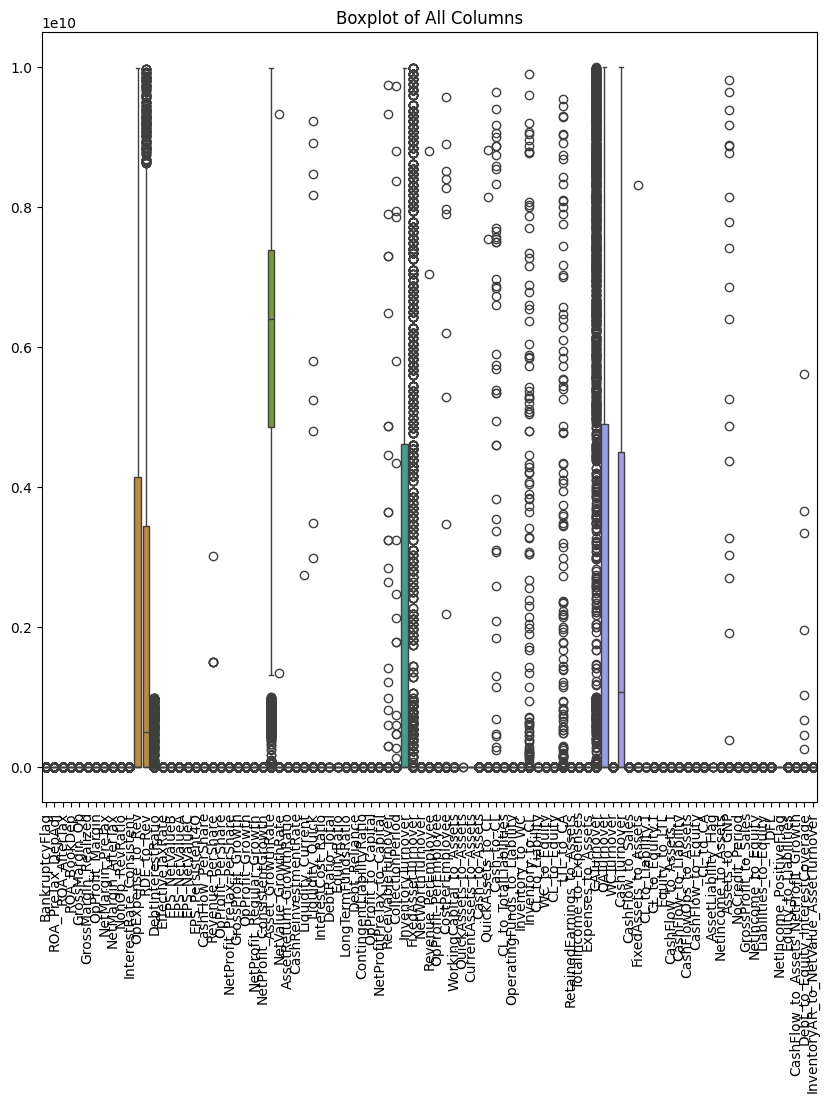

In [ ]:
#visualizing the boxplot to see the outlayers
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.boxplot(data=df)
plt.title('Boxplot of All Columns')
plt.xticks(rotation=90)


In [ ]:
#handling the outlayers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_no_outliers = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(f"Original shape: {df.shape}")
print(f"After outlier removal: {df_no_outliers.shape}")


Original shape: (6819, 93)
After outlier removal: (461, 93)


In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(96,96))
sns.boxplot(data=df)
plt.title('Boxplot of All Columns')
plt.xticks(rotation=90)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92],
 [Text(0, 0, 'BankruptcyFlag'),
  Text(1, 0, 'ROA_PreTax_DepAdj'),
  Text(2, 0, 'ROA_AfterTax'),
  Text(3, 0, 'ROA_BookDep'),
  Text(4, 0, 'GrossMargin_Op'),
  Text(5, 0, 'GrossMargin_Realized'),
  Text(6, 0, 'OpProfit_Margin'),
  Text(7, 0, 'NetMargin_PreTax'),
  Text(8, 0, 'NetMargin_AfterTax'),
  Text(9, 0, 'NonOp_RevRatio'),
  Text(10, 0, 'InterestRate_Consistent'),
  Text(11, 0, 'OpExpense_to_Rev'),
  Text(12, 0, 'RDE_to_Rev'),
  Text(13, 0, 

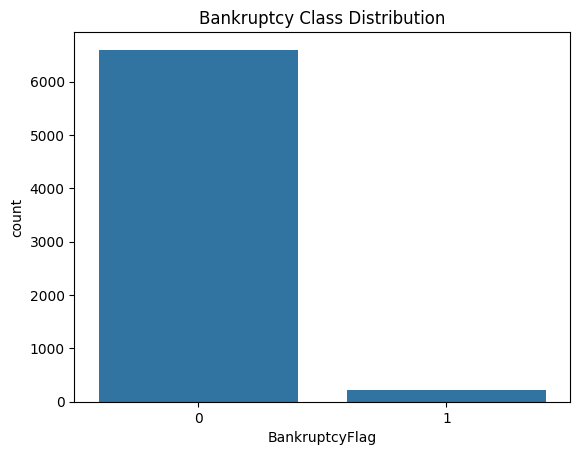

,proportion
BankruptcyFlag,
0,0.967737
1,0.032263


In [ ]:
#seeing how the data target variable values are classified
sns.countplot(data=df, x='BankruptcyFlag')
plt.title('Bankruptcy Class Distribution')
plt.show()

df['BankruptcyFlag'].value_counts(normalize=True)


In [ ]:
#features selecting
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

X = df.drop('BankruptcyFlag', axis=1)
y = df['BankruptcyFlag']

bestfeatures = SelectKBest(score_func=chi2, k=60)
fit = bestfeatures.fit(X,y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X.columns)

featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']

print(featureScores.nlargest(60,'Score'))

                                    Specs         Score
53                             Cash_to_CL  2.901545e+11
70                  FixedAssets_to_Assets  2.495621e+11
27                    NetValue_GrowthRate  2.421293e+11
43                     FixedAssetTurnover  2.200229e+11
45                    Revenue_PerEmployee  8.633138e+10
81                          Assets_to_GNP  6.391313e+10
31                        Liquidity_Quick  3.059892e+10
66                             QATurnover  2.391564e+10
26                       Asset_GrowthRate  2.051825e+10
11                             RDE_to_Rev  1.385736e+10
68                           CashTurnover  7.747258e+09
65                             CATurnover  6.456970e+09
90        Debt_to_Equity_InterestCoverage  3.749700e+09
12                      DebtInterestRatio  2.584786e+09
41                       CollectionPeriod  1.959675e+09
10                       OpExpense_to_Rev  1.325486e+09
40                     ReceivableTurnover  9.328

In [ ]:
from imblearn.over_sampling import SMOTE
x=df[featureScores.nlargest(60,'Score')['Specs'].tolist()]
y=df['BankruptcyFlag']

In [ ]:
#print only first 2 rows of scaled data
print(x[:2])

   Cash_to_CL  FixedAssets_to_Assets  NetValue_GrowthRate  FixedAssetTurnover  \
0    0.000147               0.424206             0.000327        1.165010e-04   
1    0.001384               0.468828             0.000443        7.190000e+08   

   Revenue_PerEmployee  Assets_to_GNP  Liquidity_Quick    QATurnover  \
0             0.034164       0.009219         0.001208  6.550000e+09   
1             0.006889       0.008323         0.004039  7.700000e+09   

   Asset_GrowthRate  RDE_to_Rev  ...  CashFlowOps_to_Assets  Equity_to_LTL  \
0      4.980000e+09         0.0  ...               0.520382       0.126549   
1      6.110000e+09         0.0  ...               0.567101       0.120916   

   RetainedEarnings_to_Assets  LongTermFundsRatio  CL_to_Liability  \
0                    0.903225            0.005024         0.676269   
1                    0.931065            0.005059         0.308589   

   CL_to_Liability.1  OpProfit_PerEmployee  Debt_Reliance  \
0           0.676269            

In [ ]:
# Balancing the values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
from imblearn.combine import SMOTEENN
x_train_smote, y_train_smote = SMOTEENN(random_state=42).fit_resample(x_train, y_train)

sc=StandardScaler()
x_train_smote=sc.fit_transform(x_train_smote)
x_test=sc.transform(x_test)
print("Distribution of BankruptcyFlag in the original training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of BankruptcyFlag in the resampled training set:")
print(y_train_smote.value_counts(normalize=True))


Distribution of BankruptcyFlag in the original training set:
BankruptcyFlag
0    0.967736
1    0.032264
Name: proportion, dtype: float64

Distribution of BankruptcyFlag in the resampled training set:
BankruptcyFlag
1    0.535389
0    0.464611
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score


In [ ]:
#taking training variables from the balanced values
x_train=x_train_smote
y_train=y_train_smote
x_test=x_test
y_test=y_test

In [ ]:
#implementing logestic regression model

log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)
y_pred=log_reg.predict(x_test)
accuracy_score(y_test,y_pred)

0.8717008797653959

In [ ]:
#classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.17      0.77      0.28        44

    accuracy                           0.87      1364
   macro avg       0.58      0.82      0.60      1364
weighted avg       0.96      0.87      0.91      1364



In [ ]:
#confusion matrix
print(confusion_matrix(y_test,y_pred))


[[1155  165]
 [  10   34]]


In [ ]:
#implementing randomforest model
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1320
           1       0.37      0.75      0.49        44

    accuracy                           0.95      1364
   macro avg       0.68      0.85      0.73      1364
weighted avg       0.97      0.95      0.96      1364

[[1263   57]
 [  11   33]]


In [ ]:
#implementing xgboost model
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
y_pred=xgb.predict(x_test)
accuracy_score(y_test,y_pred)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.37      0.68      0.48        44

    accuracy                           0.95      1364
   macro avg       0.68      0.82      0.73      1364
weighted avg       0.97      0.95      0.96      1364

[[1269   51]
 [  14   30]]


In [ ]:
#keep the selected features in an array
selected_features = featureScores.nlargest(10,'Score')['Specs'].tolist()


In [ ]:
#implementing xgboost model
xgb.save_model("Bankruptcy10.h5")

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [18:03:14] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)


In [ ]:
xgb.save_model("bankruptcy_model.h5")

In [ ]:
from google.colab import files
files.download("Bankruptcy10.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
joblib.dump(xgb, "bankruptcy_model.pkl")

['bankruptcy_model.pkl']